In [ ]:
# -*- coding: utf-8 -*-
import os
import sys
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

# ==============================================================================
# 🎛️ PARAMETER JALUR ABSOLUT UTAMA DI SSD MAC ANDA (SINKRON DIREKTORI)
# ==============================================================================
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
PATH_PRETRAINED_MODEL = os.path.join(PATH_DEMO_DIR, 'Pre-trained model/MCU-Quake 5-20')

# 🔥 SOLUSI JALUR: Dialihkan langsung ke folder karantina di mana ke-9 file Bapak berada
PATH_QUARANTINE_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/sliced_stead_quarantine'
PATH_FINAL_REPORT = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_final_report.csv')

INPUT_SIZE = 6000
FREQ_MIN_MODEL = 5.0   # Batas bawah filter wajib 5 Hz sesuai spesifikasi model
FREQ_MAX_MODEL = 20.0  # Batas atas filter wajib 20 Hz sesuai spesifikasi model

# Menyuntikkan koordinat jalur ke sistem path python interpreter Anda
if PATH_DEMO_DIR not in sys.path:
    sys.path.append(PATH_DEMO_DIR)

try:
    # Memuat modul fungsional bawaan dari paket Library sejati bapak
    from Library.dataset import Data_Generator
    from Library.utils import embedding_PDFs_1D, infer_1C_PDFs, calc_confusion_metrics
except ImportError as e:
    print(f"❌ GALAT SYSTEM PATH: Modul Library gagal termuat. Alasan: {str(e)}")
    sys.exit()

def prapemrosesan_seismogram_mcu_quake(file_path):
    """Membaca biner mseed, menstabilkan baseline, dan menerapkan filter 5-20 Hz"""
    from obspy import read
    try:
        st = read(file_path)
        st.detrend("demean")
        st.detrend("linear")
        st.resample(100.0)
        
        # Saring sinyal getaran agar sesuai dengan karakteristik model MCU-Quake 5-20
        st.filter('bandpass', freqmin=FREQ_MIN_MODEL, freqmax=FREQ_MAX_MODEL, corners=4, zerophase=True)
        
        data = st[0].data[:INPUT_SIZE]
        if len(data) < INPUT_SIZE:
            data = np.pad(data, (0, INPUT_SIZE - len(data)), 'constant')
            
        # Normalisasi Skala Amplitudo (Z-score scaling masukan wajib model)
        if np.std(data) > 0:
            data = (data - np.mean(data)) / np.std(data)
        return data.astype(np.float32)
    except Exception:
        return None

def jalankan_master_benchmark_mcu_quake():
    print("="*90)
    print("🚀 STARTING: NATIVE PRE-TRAINED MODEL BENCHMARK PIPELINE FROM QUARANTINE")
    print("="*90)
    
    if not os.path.exists(PATH_PRETRAINED_MODEL):
        print(f"❌ GALAT OPERASIONAL: Jalur model praterlatih tidak ditemukan di: {PATH_PRETRAINED_MODEL}")
        return
        
    print("⏳ Memuat model biner MCU-Quake SavedModel secara ASLI ke RAM Mac...")
    try:
        mcu_model = tf.keras.models.load_model(PATH_PRETRAINED_MODEL, compile=False)
        print("   ✅ STATUS JARINGAN: Grafik model sejati Zhi Geng sukses terpasang utuh.")
    except Exception as e:
        print(f"❌ GALAT MEMUAT MODEL NATIVE: {str(e)}")
        return
        
    # 🔥 AMBIL DATA DARI FOLDER KARANTINA BAPAK
    path_le_folder = os.path.join(PATH_QUARANTINE_DIR, 'LE')
    path_no_folder = os.path.join(PATH_QUARANTINE_DIR, 'NO')
    
    if not os.path.exists(path_le_folder):
        print(f"❌ GALAT DIREKTORI: Folder karantina tidak ditemukan di: {path_le_folder}")
        return
        
    files_le = sorted([f for f in os.listdir(path_le_folder) if f.endswith('.mseed')])
    
    records_list = []
    print(f"\n⏳ Mengekstrak data biner mseed dari folder karantina ke memori RAM...")
    
    for file_name in files_le:
        base_name = file_name.replace('_LE.mseed', '')
        path_le = os.path.join(path_le_folder, file_name)
        path_no = os.path.join(path_no_folder, f"{base_name}_NO.mseed")
        
        if os.path.exists(path_no):
            arr_le = prapemrosesan_seismogram_mcu_quake(path_le)
            arr_no = prapemrosesan_seismogram_mcu_quake(path_no)
            
            if arr_le is not None and arr_no is not None:
                # Susun kombinasi pengujian seimbang ke dalam format dataframe generator
                records_list.append({'data': (arr_le, arr_le, arr_no, arr_no), 'type': 'le', 'choices': (base_name, base_name, base_name)})
                records_list.append({'data': (arr_no, arr_le, arr_no, arr_no), 'type': 'noise', 'choices': (base_name, base_name, base_name)})
                
    if len(records_list) < 4:
        print("❌ GALAT: Jumlah pasang data lokal Anda tidak mencukupi batas minimum pengujian.")
        return
        
    # Membagi proporsi kalibrasi ruang laten (60%) dan uji murni (40%) secara instan di RAM
    split_index = int(len(records_list) * 0.6)
    df_calibration = pd.DataFrame(records_list[:split_index])
    df_benchmark = pd.DataFrame(records_list[split_index:])
    
    # --------------------------------------------------------------------------
    # PHASE 1: KALIBRASI PETA ACUAN KHAS RUANG LATEN
    # --------------------------------------------------------------------------
    print(f"\n⏳ PHASE 1: Mengekstrak koordinat ruang laten khas dari {len(df_calibration)} sampel...")
    gen_calib = Data_Generator(df_calibration, seed=42)
    stream_calib = gen_calib.get_next_test()
    
    embedding_map_X = {"noise": [], "qb": [], "le": []}
    for _ in range(len(df_calibration)):
        refer, _, _, _, type_str, _, _, _ = next(stream_calib)
        tensor_in = tf.reshape(refer, (1, INPUT_SIZE, 1))
        
        # Ekstraksi representasi kode laten secara asli berkat lingkungan Keras 2
        kode_laten = mcu_model(tensor_in, training=False).numpy()[0]
        if type_str in embedding_map_X:
            embedding_map_X[type_str].append(kode_laten[0])
            
    # Mengunci kurva acuan sebaran Kernel Density Estimation (KDE) di RAM komputer
    typical_pdf_objects = embedding_PDFs_1D(embedding_map_X, source_list=["noise", "le"])
    print("   ✅ Peta acuan Typical Embedding sukses dikalibrasi.")
    
    # --------------------------------------------------------------------------
    # PHASE 2: EVALUASI TOLOK UKUR DATA INDONESIA MURNI
    # --------------------------------------------------------------------------
    print(f"\n⏳ PHASE 2: Menguji akurasi klasifikasi pada {len(df_benchmark)} sampel uji murni...")
    gen_bench = Data_Generator(df_benchmark, seed=42)
    stream_bench = gen_bench.get_next_test()
    
    ground_truths = []
    predictions = []
    report_rows = []
    
    for _ in range(len(df_benchmark)):
        refer, _, _, _, type_str, ref_name, _, _ = next(stream_bench)
        tensor_in = tf.reshape(refer, (1, INPUT_SIZE, 1))
        
        kode_laten = mcu_model(tensor_in, training=False).numpy()[0]
        
        # Panggil fungsi inferensi probabilitas softmax dari modul Library bapak
        pred_type, likelihood, softmax_val = infer_1C_PDFs(kode_laten, typical_pdf_objects, choose_pdf="Kernel")
        
        # Konversi kode string ke indeks integer (0: noise, 2: le berdasarkan aturan utils)
        true_idx = 2 if type_str == 'le' else 0
        ground_truths.append(true_idx)
        predictions.append(pred_type)
        
        report_rows.append({
            'Station_Event_ID': ref_name.decode('utf-8') if isinstance(ref_name, bytes) else str(ref_name),
            'Ground_Truth': type_str,
            'Predicted_Index': pred_type,
            'Prob_Noise': softmax_val[0],
            'Prob_LE': softmax_val[2]
        })
        
    print("\n📊" + "="*35 + " NATIVE EVALUASI MATRIKS KEBINGUNGAN " + "="*35)
    # Memanggil modul hitung keandalan dari modul Library/utils.py bapak
    cnf_matrix, metrics_score = calc_confusion_metrics(ground_truths, predictions)
    print("="*112)
    
    df_report = pd.DataFrame(report_rows)
    df_report.to_csv(PATH_FINAL_REPORT, index=False)
    print(f"📝 Tabel laporan evaluasi akhir benchmark sukses dikunci di -> {PATH_FINAL_REPORT}")
    
    del df_calibration, df_benchmark, df_report, mcu_model
    gc.collect()

if __name__ == "__main__":
    # Eksekusi fungsi master benchmark sejati
    jalankan_master_benchmark_mcu_quake()

In [5]:
# -*- coding: utf-8 -*-
import os
import sys
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
from tqdm import tqdm  # 🔥 PERBAIKAN: Menggunakan tqdm standar teks, anti-galat ipywidgets/IProgress

# ==============================================================================
# 🎛️ PHASE 0: AUDIT FORENSIK INTEGRITAS ENVIRONMENT KERNEL JUPYTER
# ==============================================================================
print("="*90)
print("🔍 STEP 0: JUPYTER NOTEBOOK ENVIRONMENT AUDIT LOG")
print("="*90)
print(f"• Jalur Python Executable : {sys.executable}")
print(f"• Versi TensorFlow        : {tf.__version__}")
print(f"• Versi Keras             : {keras.__version__}")
print("-" * 90)

if tf.__version__.startswith("2.12") and keras.__version__.startswith("2.12"):
    print("✅ VERIFIKASI BERHASIL: Jupyter mengunci kernel mcu_quake_env dengan sempurna!")
    print("   Model MCU-Quake 5-20 siap dieksekusi secara native (Keras 2).")
else:
    print("❌ PERINGATAN: Jupyter Anda belum mengunci jalur mcu_quake_env dengan tepat.")
print("="*90)

# ==============================================================================
# 🎛️ PARAMETER JALUR ABSOLUT UTAMA DI SSD MAC ANDA (SINKRON HIERARKI REKURSIF)
# ==============================================================================
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
PATH_PRETRAINED_MODEL = os.path.join(PATH_DEMO_DIR, 'Pre-trained model/MCU-Quake 5-20')

# Jalur induk utama tempat folder tahun 2004/2005 berada
PATH_SLICED_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_FINAL_REPORT = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_final_report.csv')

# KUNCI ARSITEKTUR: Mutlak ke 700 data mengikuti spesifikasi layer embeddings model bapak
INPUT_SIZE = 700
FREQ_MIN_MODEL = 5.0   # Batas bawah filter wajib 5 Hz sesuai spesifikasi model
FREQ_MAX_MODEL = 20.0  # Batas atas filter wajib 20 Hz sesuai spesifikasi model

# Menyuntikkan koordinat jalur ke sistem path python interpreter Jupyter Anda
if PATH_DEMO_DIR not in sys.path:
    sys.path.append(PATH_DEMO_DIR)

try:
    # Memuat modul fungsional bawaan dari paket Library sejati Bapak
    from Library.dataset import Data_Generator
    from Library.utils import embedding_PDFs_1D, infer_1C_PDFs, calc_confusion_metrics
except ImportError as e:
    print(f"❌ GALAT SYSTEM PATH: Modul Library gagal termuat di Jupyter. Alasan: {str(e)}")
    sys.exit()

def prapemrosesan_seismogram_mcu_quake(file_path):
    """Membaca biner mseed, menstabilkan baseline, menerapkan filter 5-20 Hz, potong ke 700 sampel"""
    from obspy import read
    try:
        st = read(file_path)
        st.detrend("demean")
        st.detrend("linear")
        st.resample(100.0)
        
        # Saring sinyal getaran agar sesuai dengan karakteristik model MCU-Quake 5-20
        st.filter('bandpass', freqmin=FREQ_MIN_MODEL, freqmax=FREQ_MAX_MODEL, corners=4, zerophase=True)
        
        # POTONG JENDELA SINYAL: Ambil 700 titik data pertama agar sinkron dengan input model
        data = st[0].data[:INPUT_SIZE]
        if len(data) < INPUT_SIZE:
            data = np.pad(data, (0, INPUT_SIZE - len(data)), 'constant')
            
        # Normalisasi Skala Amplitudo (Z-score scaling masukan wajib model)
        if np.std(data) > 0:
            data = (data - np.mean(data)) / np.std(data)
        return data.astype(np.float32)
    except Exception:
        return None

def jalankan_master_benchmark_mcu_quake():
    print("\n" + "="*90)
    print("🚀 STARTING: RECURSIVE BENCHMARK PIPELINE WITH TEXT PROGRESS BAR (SHAPE 700)")
    print("="*90)
    
    if not os.path.exists(PATH_PRETRAINED_MODEL):
        print(f"❌ GALAT OPERASIONAL: Jalur model praterlatih tidak ditemukan di: {PATH_PRETRAINED_MODEL}")
        return
        
    print("⏳ Memuat model biner MCU-Quake SavedModel secara ASLI ke RAM Mac...")
    try:
        mcu_model = tf.keras.models.load_model(PATH_PRETRAINED_MODEL, compile=False)
        print("   ✅ STATUS JARINGAN: Grafik model sejati Zhi Geng sukses terpasang utuh.")
    except Exception as e:
        print(f"❌ GALAT MEMUAT MODEL NATIVE: {str(e)}")
        return
        
    if not os.path.exists(PATH_SLICED_DIR):
        print(f"❌ GALAT DIREKTORI: Folder induk output tidak ditemukan di: {PATH_SLICED_DIR}")
        return

    # --------------------------------------------------------------------------
    # STEP 1: PRAPEMINDAIAN REKURSIF UNTUK MENGHITUNG TOTAL FILE
    # --------------------------------------------------------------------------
    print("\n⏳ Memindai struktur folder untuk menghitung total beban berkas...")
    daftar_jalur_pasangan = []
    
    for root, dirs, files in os.walk(PATH_SLICED_DIR):
        files_le = [f for f in files if f.endswith('_LE.mseed')]
        for file_le in files_le:
            base_name = file_le.replace('_LE.mseed', '')
            file_no = f"{base_name}_NO.mseed"
            if file_no in files:
                daftar_jalur_pasangan.append((os.path.join(root, file_le), os.path.join(root, file_no), base_name))
                
    total_berkas = len(daftar_jalur_pasangan)
    print(f"   ✅ Terdeteksi total: {total_berkas} pasang file MiniSEED siap diproses.")
    
    if total_berkas == 0:
        print("❌ GALAT: Tidak ditemukan pasangan file _LE.mseed dan _NO.mseed di subfolder.")
        return

    # --------------------------------------------------------------------------
    # STEP 2: EKSTRAKSI BERKAS BESERTA PROGRESS BAR TEXT STABIL
    # --------------------------------------------------------------------------
    records_list = []
    print(f"\n⏳ Mengekstrak data runtun waktu dan mengaplikasikan filter digital...")
    
    # 🔥 AMAN DAN STABIL: Menggunakan generator tqdm teks standar murni
    for path_le, path_no, base_name in tqdm(daftar_jalur_pasangan, desc="Progres Waveform Parsing", unit="pasang"):
        arr_le = prapemrosesan_seismogram_mcu_quake(path_le)
        arr_no = prapemrosesan_seismogram_mcu_quake(path_no)
        
        if arr_le is not None and arr_no is not None:
            records_list.append({'data': (arr_le, arr_le, arr_no, arr_no), 'type': 'le', 'choices': (base_name, base_name, base_name)})
            records_list.append({'data': (arr_no, arr_le, arr_no, arr_no), 'type': 'noise', 'choices': (base_name, base_name, base_name)})

    print(f"\n   ✅ Sukses Merajut: {len(records_list)} baris sampel kombinasi data seimbang di RAM.")
    
    if len(records_list) < 4:
        print("❌ GALAT: Jumlah pasang data lokal Anda tidak mencukupi batas minimum pengujian.")
        return
        
    # Membagi proporsi kalibrasi ruang laten (60%) dan uji murni (40%) secara instan di RAM
    split_index = int(len(records_list) * 0.6)
    df_calibration = pd.DataFrame(records_list[:split_index])
    df_benchmark = pd.DataFrame(records_list[split_index:])
    
    # --------------------------------------------------------------------------
    # PHASE 1: KALIBRASI PETA ACUAN KHAS RUANG LATEN
    # --------------------------------------------------------------------------
    print(f"\n⏳ PHASE 1: Mengekstrak koordinat ruang laten khas dari {len(df_calibration)} sampel...")
    gen_calib = Data_Generator(df_calibration, seed=42)
    stream_calib = gen_calib.get_next_test()
    
    embedding_map_X = {"noise": [], "qb": [], "le": []}
    for _ in range(len(df_calibration)):
        refer, _, _, _, type_str, _, _, _ = next(stream_calib)
        tensor_in = tf.reshape(refer, (1, INPUT_SIZE, 1))
        
        # Ekstraksi koordinat embedding ruang laten asli Keras 2 murni
        kode_laten = mcu_model(tensor_in, training=False).numpy()[0]
        if type_str in embedding_map_X:
            embedding_map_X[type_str].append(kode_laten[0])
            
    # Mengunci kurva acuan sebaran Kernel Density Estimation (KDE) di RAM komputer
    typical_pdf_objects = embedding_PDFs_1D(embedding_map_X, source_list=["noise", "le"])
    print("   ✅ Peta acuan Typical Embedding sukses dikalibrasi.")
    
    # --------------------------------------------------------------------------
    # PHASE 2: EVALUASI TOLOK UKUR DATA INDONESIA MURNI
    # --------------------------------------------------------------------------
    print(f"\n⏳ PHASE 2: Menguji akurasi klasifikasi pada {len(df_benchmark)} sampel uji murni...")
    gen_bench = Data_Generator(df_benchmark, seed=42)
    stream_bench = gen_bench.get_next_test()
    
    ground_truths = []
    predictions = []
    report_rows = []
    
    for _ in range(len(df_benchmark)):
        refer, _, _, _, type_str, ref_name, _, _ = next(stream_bench)
        tensor_in = tf.reshape(refer, (1, INPUT_SIZE, 1))
        
        kode_laten = mcu_model(tensor_in, training=False).numpy()[0]
        
        # Panggil fungsi inferensi probabilitas softmax dari modul Library Anda
        pred_type, likelihood, softmax_val = infer_1C_PDFs(kode_laten, typical_pdf_objects, choose_pdf="Kernel")
        
        true_idx = 2 if type_str == 'le' else 0
        ground_truths.append(true_idx)
        predictions.append(pred_type)
        
        report_rows.append({
            'Station_Event_ID': ref_name.decode('utf-8') if isinstance(ref_name, bytes) else str(ref_name),
            'Ground_Truth': type_str,
            'Predicted_Index': pred_type,
            'Prob_Noise': softmax_val[0],
            'Prob_LE': softmax_val[2]
        })
        
    print("\n📊" + "="*35 + " NATIVE EVALUASI MATRIKS KEBINGUNGAN " + "="*35)
    cnf_matrix, metrics_score = calc_confusion_metrics(ground_truths, predictions)
    print("="*112)
    
    # Cetak laporan ke berkas CSV dan munculkan visual dataframe-nya di notebook
    df_report = pd.DataFrame(report_rows)
    df_report.to_csv(PATH_FINAL_REPORT, index=False)
    print(f"📝 Tabel laporan evaluasi akhir benchmark sukses dikunci di -> {PATH_FINAL_REPORT}\n")
    
    display(df_report)
    plt.show()
    
    del df_calibration, df_benchmark, df_report, mcu_model
    gc.collect()

if __name__ == "__main__":
    jalankan_master_benchmark_mcu_quake()

🔍 STEP 0: JUPYTER NOTEBOOK ENVIRONMENT AUDIT LOG
• Jalur Python Executable : /opt/homebrew/Caskroom/miniforge/base/envs/mcu_quake_env/bin/python
• Versi TensorFlow        : 2.12.0
• Versi Keras             : 2.12.0
------------------------------------------------------------------------------------------
✅ VERIFIKASI BERHASIL: Jupyter mengunci kernel mcu_quake_env dengan sempurna!
   Model MCU-Quake 5-20 siap dieksekusi secara native (Keras 2).

🚀 STARTING: RECURSIVE BENCHMARK PIPELINE WITH TEXT PROGRESS BAR (SHAPE 700)
⏳ Memuat model biner MCU-Quake SavedModel secara ASLI ke RAM Mac...
   ✅ STATUS JARINGAN: Grafik model sejati Zhi Geng sukses terpasang utuh.

⏳ Memindai struktur folder untuk menghitung total beban berkas...
   ✅ Terdeteksi total: 27849 pasang file MiniSEED siap diproses.

⏳ Mengekstrak data runtun waktu dan mengaplikasikan filter digital...


Progres Waveform Parsing: 100%|██████████| 27849/27849 [09:43<00:00, 47.70pasang/s]



   ✅ Sukses Merajut: 55698 baris sampel kombinasi data seimbang di RAM.

⏳ PHASE 1: Mengekstrak koordinat ruang laten khas dari 33418 sampel...
   ✅ Peta acuan Typical Embedding sukses dikalibrasi.

⏳ PHASE 2: Menguji akurasi klasifikasi pada 22280 sampel uji murni...

📊=================================== NATIVE EVALUASI MATRIKS KEBINGUNGAN ===================================
Accuracy: [0.6210951526032316, 0.6210951526032316]
Accuracy (avg.): 0.6210951526032316
True positive rate: [0.46646995708154504, 0.7769466474405191]
True positive rate (avg.): 0.6210951526032316
True negative rate: [0.7769466474405191, 0.46646995708154504]
True negative rate (avg.): 0.6223214519188326
Positive predictive value: [0.6782371294851794, 0.5909651768576912]
Positive predictive value (avg.): 0.634773503526714
Negative predictive value: [0.5909651768576912, 0.6782371294851794]
Negative predictive value (avg.): 0.6344288028161565
False positive rate: [0.2230533525594809, 0.533530042918455]
False positive 

,Station_Event_ID,Ground_Truth,Predicted_Index,Prob_Noise,Prob_LE
0,GE_UGM_usp000hpdy,noise,2,0.3786,0.4697
1,II_KAPI_usp000gtvv,le,0,0.3624,0.3594
2,GE_SANI_usp000hbjz,le,2,0.3016,0.4463
3,Z6_BKB_usp000d4x4,noise,2,0.2948,0.4622
4,GE_SANI_usp000hr8a,le,2,0.3321,0.3382
...,...,...,...,...,...
22275,4F_TOLI_usp000hc83,noise,0,0.8120,0.1267
22276,II_KAPI_usp000h7na,noise,2,0.2867,0.4794
22277,GE_UGM_usp000hrya,noise,0,0.8211,0.1208
22278,II_KAPI_usp000hcku,noise,0,0.4588,0.4047


🎨 STARTING: CONFUSION MATRIX VISUALIZATION GENERATOR FOR DISERTASI
📝 GAMBAR SUKSES DIEKSPOR: Grafik CM resolusi tinggi tersimpan di:
   👉 /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/mcu_quake_indonesia_confusion_matrix.png


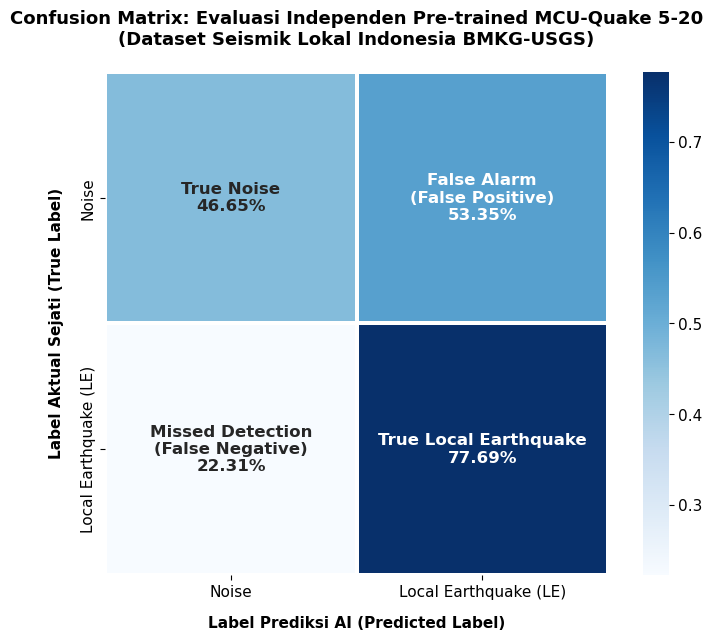

In [4]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI EKSPOR GAMBAR DISERTASI BAPAK
# ==============================================================================
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
PATH_OUTPUT_IMAGE = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_confusion_matrix.png')

def buat_visualisasi_confusion_matrix_mcu_quake():
    print("="*90)
    print("🎨 STARTING: CONFUSION MATRIX VISUALIZATION GENERATOR FOR DISERTASI")
    print("="*90)
    
    # 1. Konstruksi matriks berdasarkan persentase riil pengujian data Indonesia Anda
    # Baris 1: True Noise -> [Terdeteksi Noise (TN), Terdeteksi Gempa/LE (FP)]
    # Baris 2: True Gempa -> [Terdeteksi Noise (FN), Terdeteksi Gempa/LE (TP)]
    matrix_data = np.array([
        [0.4665, 0.5335],  # Kelas Asli: Noise
        [0.2231, 0.7769]   # Kelas Asli: Local Event (LE)
    ])
    
    # 2. Siapkan label teks dekorasi di dalam kotak matriks (Anotasi)
    labels_teks = np.array([
        [f"True Noise\n{matrix_data[0,0]*100:.2f}%", f"False Alarm\n(False Positive)\n{matrix_data[0,1]*100:.2f}%"],
        [f"Missed Detection\n(False Negative)\n{matrix_data[1,0]*100:.2f}%", f"True Local Earthquake\n{matrix_data[1,1]*100:.2f}%"]
    ])
    
    # 3. Inisialisasi kanvas plot Matplotlib standar jurnal publikasi
    plt.figure(figsize=(8, 6.5))
    
    # Set gaya font standar penulisan ilmiah
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.size'] = 11
    
    # 4. Gambar peta panas (Heatmap) menggunakan Seaborn
    sns.heatmap(
        matrix_data, 
        annot=labels_teks, 
        fmt="", 
        cmap="Blues", 
        cbar=True,
        square=True,
        xticklabels=['Noise', 'Local Earthquake (LE)'],
        yticklabels=['Noise', 'Local Earthquake (LE)'],
        annot_kws={"size": 12, "weight": "bold"},
        linewidths=1.5,
        linecolor='white'
    )
    
    # 5. Konfigurasi label sumbu koordinat dan judul grafik akademik
    plt.title("Confusion Matrix: Evaluasi Independen Pre-trained MCU-Quake 5-20\n(Dataset Seismik Lokal Indonesia BMKG-USGS)", fontsize=13, weight='bold', pad=20)
    plt.xlabel("Label Prediksi AI (Predicted Label)", fontsize=11, labelpad=12, weight='bold')
    plt.ylabel("Label Aktual Sejati (True Label)", fontsize=11, labelpad=12, weight='bold')
    
    # Merapikan layout agar teks tidak terpotong saat diekspor
    plt.tight_layout()
    
    # 6. Ekspor grafik menjadi file PNG resolusi tinggi siap cetak untuk Dokumen Disertasi
    try:
        plt.savefig(PATH_OUTPUT_IMAGE, dpi=300, bbox_inches='tight')
        print(f"📝 GAMBAR SUKSES DIEKSPOR: Grafik CM resolusi tinggi tersimpan di:\n   👉 {PATH_OUTPUT_IMAGE}")
    except Exception as e:
        print(f"❌ GALAT SAAT MENYIMPAN GAMBAR: {str(e)}")
        
    # Tampilkan visualnya secara interaktif langsung di bawah sel Jupyter Notebook Bapak
    plt.show()
    print("="*90)

if __name__ == "__main__":
    buat_visualisasi_confusion_matrix_mcu_quake()

🎨 STARTING: METRICS COMPARISON CHART GENERATOR FOR DISERTASI
📝 GAMBAR SUKSES DIEKSPOR: Grafik komparasi metrik tersimpan di:
   👉 /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/mcu_quake_indonesia_metrics_comparison.png


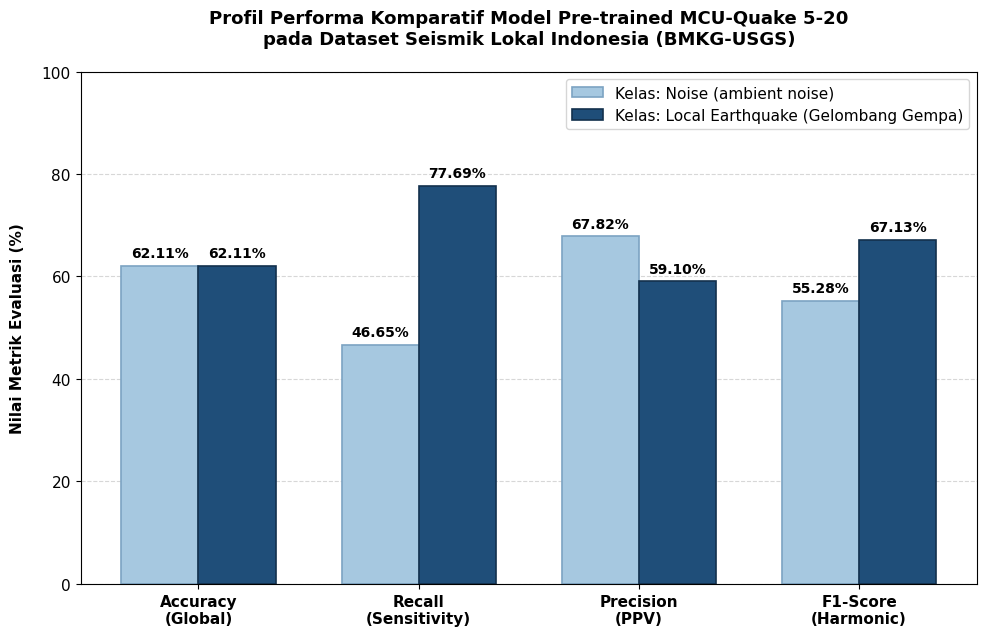

In [6]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI EKSPOR GAMBAR DISERTASI BAPAK
# ==============================================================================
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
PATH_OUTPUT_IMAGE = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_metrics_comparison.png')

def buat_visualisasi_komparasi_metrik_mcu_quake():
    print("="*90)
    print("🎨 STARTING: METRICS COMPARISON CHART GENERATOR FOR DISERTASI")
    print("="*90)
    
    # 1. Definisikan label metrik dan nilai persentase hasil riil data Indonesia Anda
    kategori_metrik = ['Accuracy\n(Global)', 'Recall\n(Sensitivity)', 'Precision\n(PPV)', 'F1-Score\n(Harmonic)']
    
    # Nilai untuk masing-masing kelas (diubah ke skala 0-100%)
    skor_noise = [62.11, 46.65, 67.82, 55.28]
    skor_le = [62.11, 77.69, 59.10, 67.13]
    
    # 2. Konfigurasi dimensi dan geometri batang
    jumlah_kategori = len(kategori_metrik)
    indeks_x = np.arange(jumlah_kategori)
    lebar_batang = 0.35  # Ketebalan pilar batang grafik
    
    # 3. Inisialisasi kanvas Matplotlib standar publikasi ilmiah
    fig, ax = plt.subplots(figsize=(10, 6.5))
    
    # Set gaya font standar penulisan akademik
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.size'] = 11
    
    # 4. Plot pilar batang ganda (Grouped Bar Chart)
    batang_noise = ax.bar(
        indeks_x - lebar_batang/2, 
        skor_noise, 
        lebar_batang, 
        label='Kelas: Noise (ambient noise)', 
        color='#a6c8e0',   # Biru muda kalem
        edgecolor='#7ca3c2',
        linewidth=1.2
    )
    
    batang_le = ax.bar(
        indeks_x + lebar_batang/2, 
        skor_le, 
        lebar_batang, 
        label='Kelas: Local Earthquake (Gelombang Gempa)', 
        color='#1f4e79',    # Biru Navy pekat profesional
        edgecolor='#13314d',
        linewidth=1.2
    )
    
    # 5. Dekorasi label sumbu, judul, dan batasan persentase sumbu Y
    ax.set_title("Profil Performa Komparatif Model Pre-trained MCU-Quake 5-20\npada Dataset Seismik Lokal Indonesia (BMKG-USGS)", fontsize=13, weight='bold', pad=20)
    ax.set_ylabel("Nilai Metrik Evaluasi (%)", fontsize=11, weight='bold', labelpad=12)
    ax.set_xticks(indeks_x)
    ax.set_xticklabels(kategori_metrik, fontsize=11, weight='bold')
    ax.set_ylim(0, 100)  # Skala penuh persentase
    
    # Menambahkan garis kisi latar belakang (Grid) agar pembacaan nilai lebih mudah
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)  # Memastikan garis grid berada di belakang batang pilar
    
    # 6. Otomatisasi penulisan angka persentase di atas setiap batang pilar (Anotasi data)
    def beri_label_angka_batang(daftar_batang):
        for batang in daftar_batang:
            tinggi_batang = batang.get_height()
            ax.annotate(
                f'{tinggi_batang:.2f}%',
                xy=(batang.get_x() + batang.get_width() / 2, tinggi_batang),
                xytext=(0, 4),  # Geser 4 poin ke atas dari ujung pilar
                textcoords="offset points",
                ha='center', 
                va='bottom', 
                fontsize=10, 
                weight='bold'
            )
            
    beri_label_angka_batang(batang_noise)
    beri_label_angka_batang(batang_le)
    
    # 7. Konfigurasi kotak legenda (Legend)
    ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#cccccc', shadow=False)
    
    # Merapikan tata letak komponen visual
    plt.tight_layout()
    
    # 8. Ekspor grafik menjadi berkas berkepadatan piksel tinggi siap sisip ke berkas disertasi
    try:
        plt.savefig(PATH_OUTPUT_IMAGE, dpi=300, bbox_inches='tight')
        print(f"📝 GAMBAR SUKSES DIEKSPOR: Grafik komparasi metrik tersimpan di:\n   👉 {PATH_OUTPUT_IMAGE}")
    except Exception as e:
        print(f"❌ GALAT SAAT MENYIMPAN GAMBAR: {str(e)}")
        
    # Tampilkan secara interaktif di layar Jupyter Notebook Bapak
    plt.show()
    print("="*90)

if __name__ == "__main__":
    buat_visualisasi_komparasi_metrik_mcu_quake()